DOWNLOAD DATASET HAM10000 FROM KAGGLE

In [1]:
import os

# 1. Set Kaggle API Token directly from your UI
os.environ['KAGGLE_API_TOKEN'] = "KGAT_a197895dad19ec6eac1416560e23b94f"

# 2. Download HAM10000 dataset
print("Downloading HAM10000 dataset from Kaggle (approx. 3GB)...")
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

# 3. Unzip the dataset
print("\nExtracting data...")
!unzip -q skin-cancer-mnist-ham10000.zip -d data_ham10000
print("✅ Download and extraction completed successfully!")

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:34<00:00, 160MB/s]


Extracting data...
✅ Download and extraction completed successfully!


DATA PREPROCESSING AND BUILD CUSTOM DATASET

In [2]:
import pandas as pd
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# 1. READ METADATA FILE AND MAP LABELS
metadata = pd.read_csv('./data_ham10000/HAM10000_metadata.csv')

# Dictionary mapping 7 lesion types to descriptive names (optional for reference)
lesion_type_dict = {
    'nv': 'Melanocytic nevi', 'mel': 'Melanoma', 'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma', 'akiec': 'Actinic keratoses', 'vasc': 'Vascular lesions', 'df': 'Dermatofibroma'
}

# Convert lesion codes (dx) to numerical labels (0 to 6)
metadata['label'] = pd.Categorical(metadata['dx']).codes

# Split into Training (80%) and Testing (20%) sets with stratification
train_df, test_df = train_test_split(metadata, test_size=0.2, random_state=42, stratify=metadata['label'])

# 2. BUILD CUSTOM DATASET CLASS
class SkinCancerDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get image name and label from the DataFrame
        img_name = self.df.iloc[idx]['image_id'] + '.jpg'

        # Images are split across two directories, check both paths
        img_path = os.path.join(self.img_dir, 'HAM10000_images_part_1', img_name)
        if not os.path.exists(img_path):
            img_path = os.path.join(self.img_dir, 'HAM10000_images_part_2', img_name)

        image = Image.open(img_path).convert('RGB')
        label = self.df.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)

        return image, label

# 3. PREPROCESSING & DATA AUGMENTATION
# For skin lesions, both horizontal and vertical flips are physically meaningful
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), # Added vertical flip
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. CREATE DATALOADERS
img_dir = './data_ham10000'
train_dataset = SkinCancerDataset(train_df, img_dir, transform=train_transform)
test_dataset = SkinCancerDataset(test_df, img_dir, transform=test_transform)

trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
testloader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"✅ Setup Complete! Train images: {len(train_dataset)} | Test images: {len(test_dataset)}")

✅ Setup Complete! Train images: 8012 | Test images: 2003


SAMPLES

Generating visual samples grid...
✅ Samples grid generated and saved successfully as 'ham10000_samples.png'!


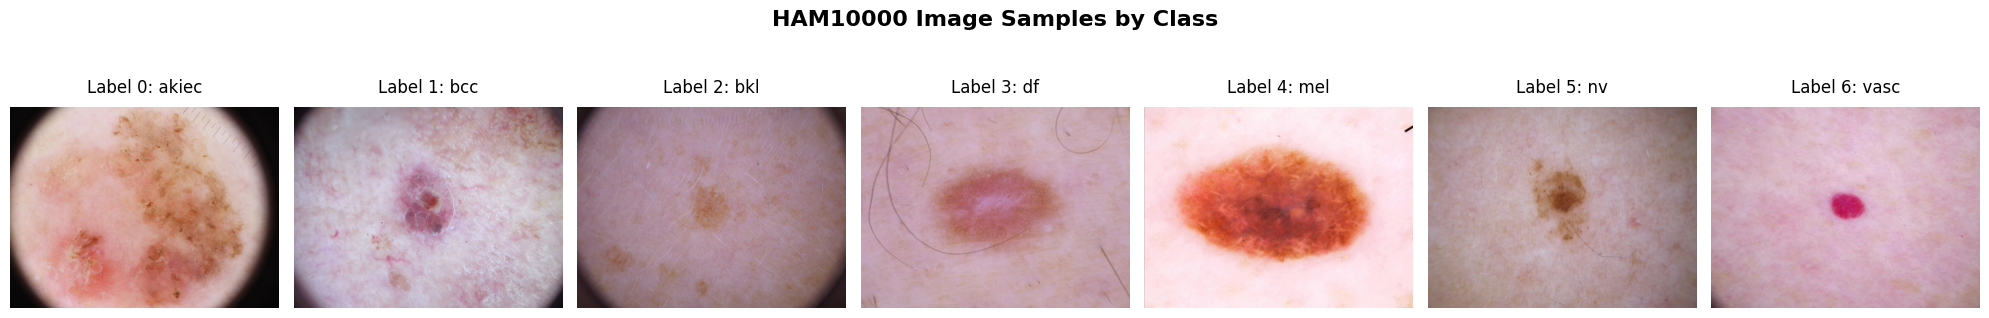

In [3]:
import matplotlib.pyplot as plt
import numpy as np

print("Generating visual samples grid...")

# 1. Get one random image from each class
sample_images = []
sample_titles = []

# Group metadata by label and pick 1 random row from each
for label in range(7):
    # Find a random row matching this label
    sample_row = metadata[metadata['label'] == label].sample(1).iloc[0]

    # Get image path (same logic as custom dataset)
    img_name = sample_row['image_id'] + '.jpg'
    img_path = os.path.join(img_dir, 'HAM10000_images_part_1', img_name)
    if not os.path.exists(img_path):
        img_path = os.path.join(img_dir, 'HAM10000_images_part_2', img_name)

    # Open image
    img = Image.open(img_path)
    sample_images.append(img)

    # Get the disease code (e.g., 'nv', 'mel')
    dx_code = sample_row['dx']
    sample_titles.append(f"Label {label}: {dx_code}")

# 2. Create a Matplotlib figure (1 row, 7 columns)
fig, axes = plt.subplots(1, 7, figsize=(20, 3))
fig.suptitle("HAM10000 Image Samples by Class", fontsize=16, fontweight='bold', y=1.1)

# 3. Plot each image
for i, ax in enumerate(axes):
    ax.imshow(sample_images[i])
    ax.set_title(sample_titles[i], fontsize=12, pad=10)
    ax.axis('off') # Hide axes for cleaner look

# 4. Save and show
plt.tight_layout()
file_name = 'ham10000_samples.png'
plt.savefig(file_name, dpi=300, bbox_inches='tight')
print(f"✅ Samples grid generated and saved successfully as '{file_name}'!")
plt.show()

Augmented Sample

Generating Data Augmentation samples...
✅ Saved successfully as 'augmentation_sample.png'!


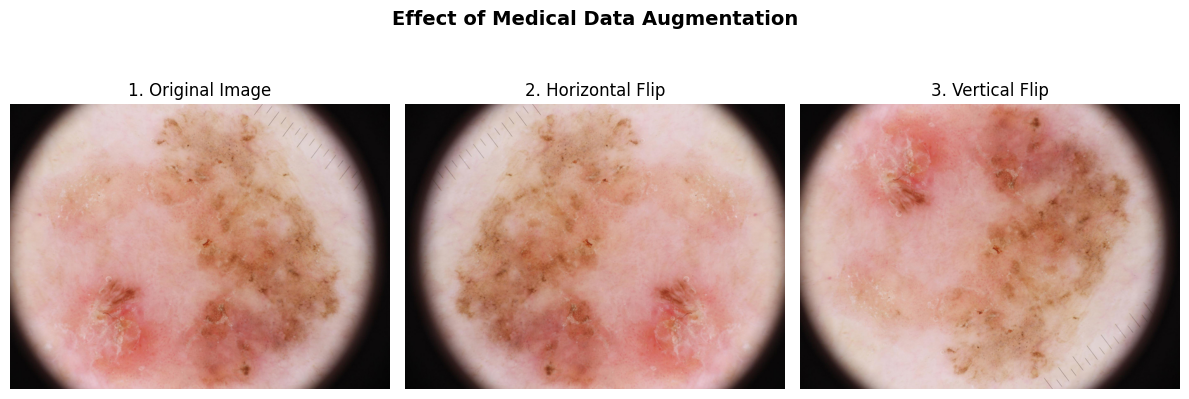

In [4]:
import torchvision.transforms as T
import matplotlib.pyplot as plt

print("Generating Data Augmentation samples...")

# Lấy 1 bức ảnh ngẫu nhiên từ tập sample_images lúc nãy
sample_img = sample_images[0] # Lấy ảnh đầu tiên làm ví dụ

# Áp dụng thử các phép biến đổi
flip_h = T.RandomHorizontalFlip(p=1.0)(sample_img)
flip_v = T.RandomVerticalFlip(p=1.0)(sample_img)

# Vẽ hình
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Effect of Medical Data Augmentation", fontsize=14, fontweight='bold', y=1.05)

axes[0].imshow(sample_img)
axes[0].set_title("1. Original Image", fontsize=12)

axes[1].imshow(flip_h)
axes[1].set_title("2. Horizontal Flip", fontsize=12)

axes[2].imshow(flip_v)
axes[2].set_title("3. Vertical Flip", fontsize=12)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
file_name = 'augmentation_sample.png'
plt.savefig(file_name, dpi=300, bbox_inches='tight')
print(f"✅ Saved successfully as '{file_name}'!")
plt.show()

DISTRIBUTION OF DATASET HAM10000

Generating class distribution chart...


/tmp/ipykernel_1670/322862519.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="Blues_r")


✅ Chart generated and saved successfully as 'ham10000_distribution.png'!


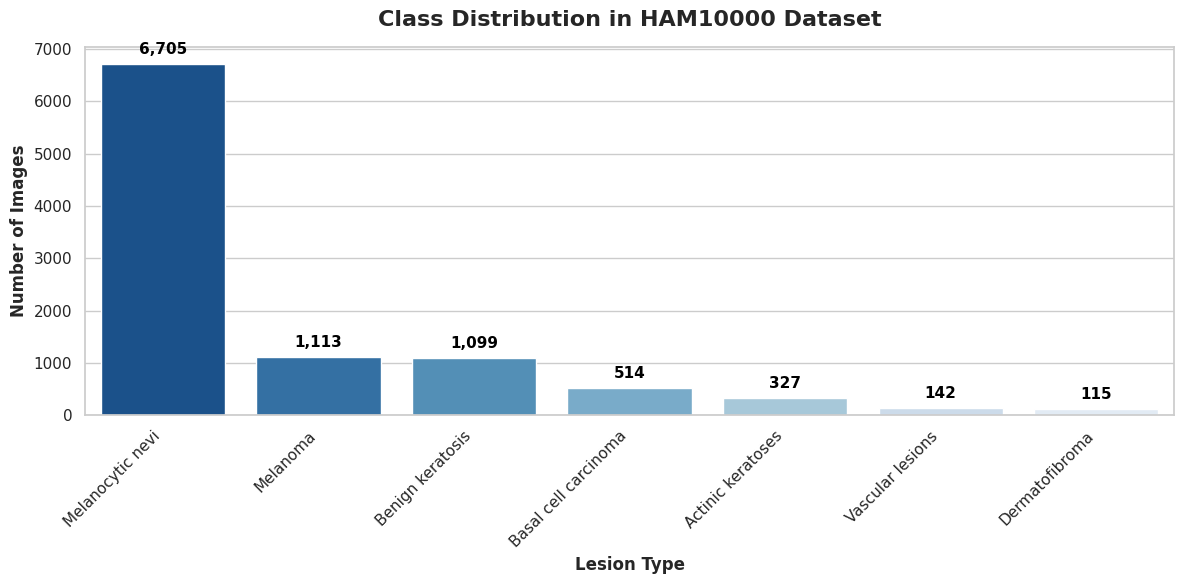

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating class distribution chart...")

# 1. Get the counts of each class from the metadata DataFrame
class_counts = metadata['dx'].value_counts()

# 2. Map the short codes to full descriptive names for a professional chart
lesion_names = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
class_counts.index = class_counts.index.map(lesion_names)

# 3. Setup the plot style and size
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 4. Create the bar plot (using a nice blue color palette)
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="Blues_r")

# 5. Add titles and labels
plt.title('Class Distribution in HAM10000 Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Lesion Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12, fontweight='bold')

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right', fontsize=11)

# 6. Add exact numbers on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

# 7. Save the figure to Colab's disk in high resolution (300 dpi)
plt.tight_layout()
file_name = 'ham10000_distribution.png'
plt.savefig(file_name, dpi=300)

print(f"✅ Chart generated and saved successfully as '{file_name}'!")

# 8. Display the plot in the notebook
plt.show()

FULL FINE-TUNING AND EVALUATE RESNET-18

In [3]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# 1. DEFINE DEVICE (Bắt buộc phải ra "cuda" nhé!)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. LOAD PRE-TRAINED RESNET-18
print("Loading pre-trained ResNet-18...")
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify the final classification layer for 7 classes
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 7)
resnet_model = resnet_model.to(device)

# 3. LOSS FUNCTION & OPTIMIZER
criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet_model.parameters(), lr=0.001)

# 4. TRAINING LOOP (FULL FINE-TUNING)
num_epochs = 5
train_losses_resnet = []
test_accuracies_resnet = []

print(f"\n🚀 STARTING FULL FINE-TUNING FOR RESNET-18 ({num_epochs} Epochs)...")
start_time = time.time()

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    resnet_model.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        # SỬA LỖI TẠI ĐÂY: Ép kiểu labels sang dạng Long (int64)
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.long)

        optimizer_resnet.zero_grad()
        outputs = resnet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(trainloader.dataset)
    train_losses_resnet.append(epoch_loss)

    # --- EVALUATION PHASE ---
    resnet_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            # Ép kiểu cho cả lúc test
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.long)

            outputs = resnet_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    test_accuracies_resnet.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_loss:.4f} | Test Acc: {epoch_acc:.2f}%")

end_time = time.time()
print(f"\n✅ ResNet-18 Training Complete! Total time: {(end_time - start_time)/60:.2f} minutes")

Using device: cuda
Loading pre-trained ResNet-18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]



🚀 STARTING FULL FINE-TUNING FOR RESNET-18 (5 Epochs)...
Epoch [1/5] | Train Loss: 0.7599 | Test Acc: 74.74%
Epoch [2/5] | Train Loss: 0.6314 | Test Acc: 69.75%
Epoch [3/5] | Train Loss: 0.5862 | Test Acc: 76.29%
Epoch [4/5] | Train Loss: 0.5455 | Test Acc: 65.05%
Epoch [5/5] | Train Loss: 0.5106 | Test Acc: 77.78%

✅ ResNet-18 Training Complete! Total time: 6.88 minutes


In [4]:
# 1. SAVE RESNET-18 WEIGHTS
torch.save(resnet_model.state_dict(), 'resnet18_ham10000_full.pth')
print("✅ ResNet-18 weights saved successfully!")

✅ ResNet-18 weights saved successfully!


TRAIN VIT-B_16

In [5]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# 1. SAVE RESNET-18 WEIGHTS
torch.save(resnet_model.state_dict(), 'resnet18_ham10000_full.pth')
print("✅ ResNet-18 weights saved successfully!")

# ==========================================
# 2. LOAD PRE-TRAINED VIT-B_16
# ==========================================
print("\nLoading pre-trained ViT-B_16...")
vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

# Modify the final classification head for 7 classes (HAM10000 dataset)
num_ftrs_vit = vit_model.heads.head.in_features
vit_model.heads.head = nn.Linear(num_ftrs_vit, 7)
vit_model = vit_model.to(device)

# 3. LOSS FUNCTION & OPTIMIZER
criterion = nn.CrossEntropyLoss()
# Use a smaller Learning Rate (0.0001) for ViT to prevent catastrophic forgetting
optimizer_vit = optim.Adam(vit_model.parameters(), lr=0.0001)

# 4. TRAINING LOOP (FULL FINE-TUNING)
num_epochs = 5
train_losses_vit = []
test_accuracies_vit = []

print(f"\n🚀 STARTING FULL FINE-TUNING FOR VIT-B_16 ({num_epochs} Epochs)...")
start_time_vit = time.time()

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    vit_model.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.long) # Cast labels to Long type

        optimizer_vit.zero_grad()
        outputs = vit_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_vit.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(trainloader.dataset)
    train_losses_vit.append(epoch_loss)

    # --- EVALUATION PHASE ---
    vit_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.long)

            outputs = vit_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    test_accuracies_vit.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_loss:.4f} | Test Acc: {epoch_acc:.2f}%")

end_time_vit = time.time()
print(f"\n✅ ViT-B_16 Training Complete! Total time: {(end_time_vit - start_time_vit)/60:.2f} minutes")

# 5. SAVE VIT-B_16 WEIGHTS
torch.save(vit_model.state_dict(), 'vit_b16_ham10000_full.pth')
print("✅ ViT-B_16 weights saved successfully!")

✅ ResNet-18 weights saved successfully!

Loading pre-trained ViT-B_16...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 177MB/s]



🚀 STARTING FULL FINE-TUNING FOR VIT-B_16 (5 Epochs)...
Epoch [1/5] | Train Loss: 0.7391 | Test Acc: 78.08%
Epoch [2/5] | Train Loss: 0.5148 | Test Acc: 79.88%
Epoch [3/5] | Train Loss: 0.4244 | Test Acc: 82.83%
Epoch [4/5] | Train Loss: 0.3550 | Test Acc: 83.33%
Epoch [5/5] | Train Loss: 0.2780 | Test Acc: 84.62%

✅ ViT-B_16 Training Complete! Total time: 26.29 minutes
✅ ViT-B_16 weights saved successfully!


Error analysis: categorizing errors (confusion, hard examples), illustrating a few
misclassified cases with brief explanation

Loading the saved ViT-B_16 weights for evaluation...

Running inference on the test set to collect predictions and ground truths...
✅ Inference complete. Total time: 23.55 seconds.

Plotting the training history graphs...


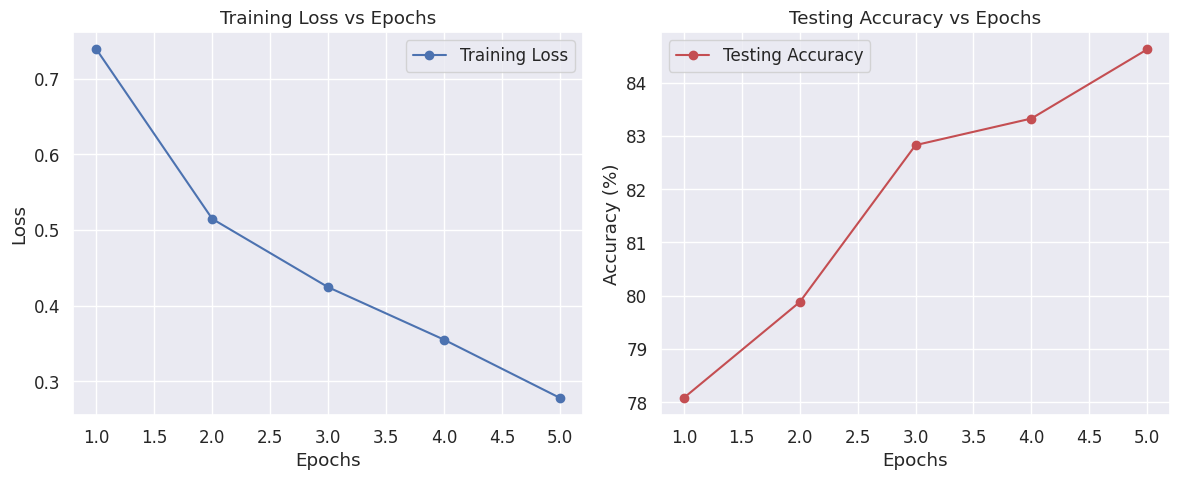

✅ Training history graphs generated.

Generating and plotting the confusion matrix...


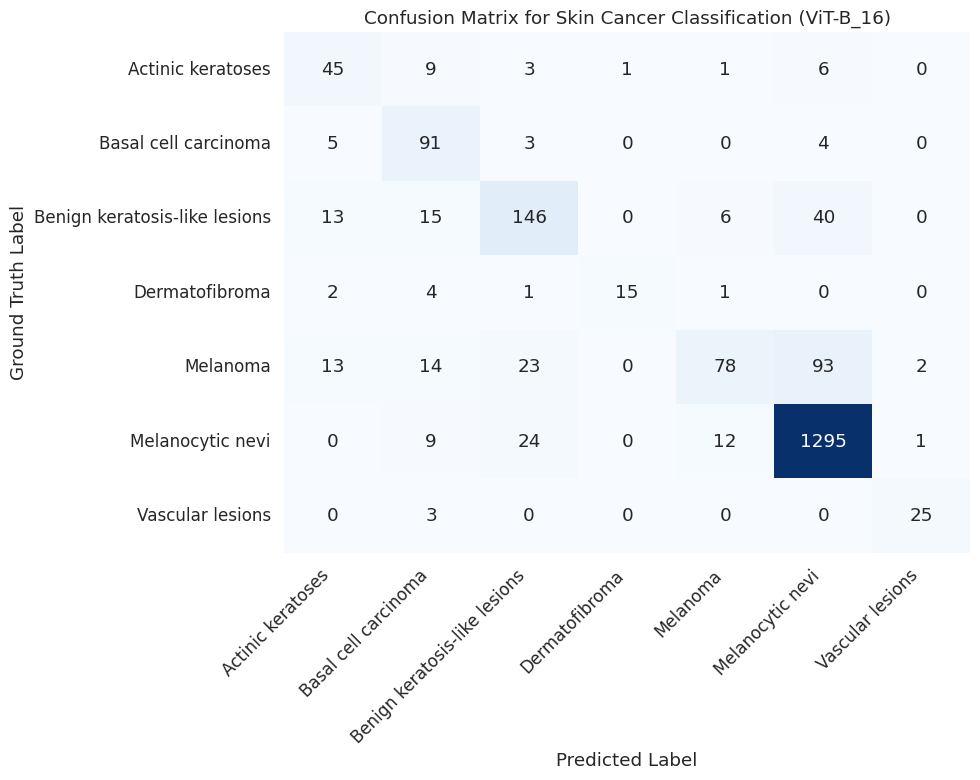

✅ Confusion matrix graph generated.

================ Classification Report ================ 
                               precision    recall  f1-score   support

            Actinic keratoses       0.58      0.69      0.63        65
         Basal cell carcinoma       0.63      0.88      0.73       103
Benign keratosis-like lesions       0.73      0.66      0.70       220
               Dermatofibroma       0.94      0.65      0.77        23
                     Melanoma       0.80      0.35      0.49       223
             Melanocytic nevi       0.90      0.97      0.93      1341
             Vascular lesions       0.89      0.89      0.89        28

                     accuracy                           0.85      2003
                    macro avg       0.78      0.73      0.73      2003
                 weighted avg       0.85      0.85      0.83      2003

✅ Evaluation complete. You are now ready for your final report!


In [14]:
import time
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. LOAD THE SAVED VIT MODEL WEIGHTS
print("Loading the saved ViT-B_16 weights for evaluation...")
# Create a fresh ViT model with the correct head size
vit_eval_model = models.vit_b_16(weights=None) # No need to load default weights again
num_ftrs_vit = vit_eval_model.heads.head.in_features
vit_eval_model.heads.head = nn.Linear(num_ftrs_vit, 7) # HAM10000 has 7 classes

# Load your custom-trained weights
vit_eval_model.load_state_dict(torch.load('vit_b16_ham10000_full.pth'))
vit_eval_model = vit_eval_model.to(device)
vit_eval_model.eval()

# 2. RUN INFERENCE ON THE TEST SET TO GET PREDICTIONS
print("\nRunning inference on the test set to collect predictions and ground truths...")
all_preds = []
all_labels = []

start_time_eval = time.time()
with torch.no_grad():
    for inputs, labels in testloader:
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.long)

        outputs = vit_eval_model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

end_time_eval = time.time()
print(f"✅ Inference complete. Total time: {(end_time_eval - start_time_eval):.2f} seconds.")

# ==========================================
# 3. ACTION 1: PLOT TRAINING HISTORY
# ==========================================
print("\nPlotting the training history graphs...")
epochs = range(1, len(train_losses_vit) + 1)

plt.figure(figsize=(12, 5))

# Plot Train Loss vs Epochs
plt.subplot(1, 2, 1) # Create the left subplot
plt.plot(epochs, train_losses_vit, 'bo-', label='Training Loss')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Test Accuracy vs Epochs
plt.subplot(1, 2, 2) # Create the right subplot
plt.plot(epochs, test_accuracies_vit, 'ro-', label='Testing Accuracy')
plt.title('Testing Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout() # Prevent labels from overlapping
plt.show() # Display the plots in the notebook
print("✅ Training history graphs generated.")

# ==========================================
# 4. ACTION 2: CREATE & PLOT CONFUSION MATRIX
# ==========================================
print("\nGenerating and plotting the confusion matrix...")
# List of descriptive class names from HAM10000, in order of label index (0 to 6)
class_names = [
    'Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions',
    'Dermatofibroma', 'Melanoma', 'Melanocytic nevi', 'Vascular lesions'
]

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Create the display object
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot the matrix using Seaborn for better styling
plt.figure(figsize=(10, 8))
sns.set(font_scale=1.1) # Scale font size for better readability
ax = sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('Ground Truth Label')
plt.title('Confusion Matrix for Skin Cancer Classification (ViT-B_16)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.yticks(rotation=0)
plt.tight_layout()
plt.show() # Display the confusion matrix
print("✅ Confusion matrix graph generated.")

# 5. PRINT A DETAILED CLASSIFICATION REPORT
print("\n================ Classification Report ================ ")
print(classification_report(all_labels, all_preds, target_names=class_names))
print("======================================================= ")
print("✅ Evaluation complete. You are now ready for your final report!")

Misclassified Samples

Searching for False Negative examples (True: Melanoma, Pred: Nevi)...
✅ Đã lưu thành công ảnh 'misclassified_samples.png'


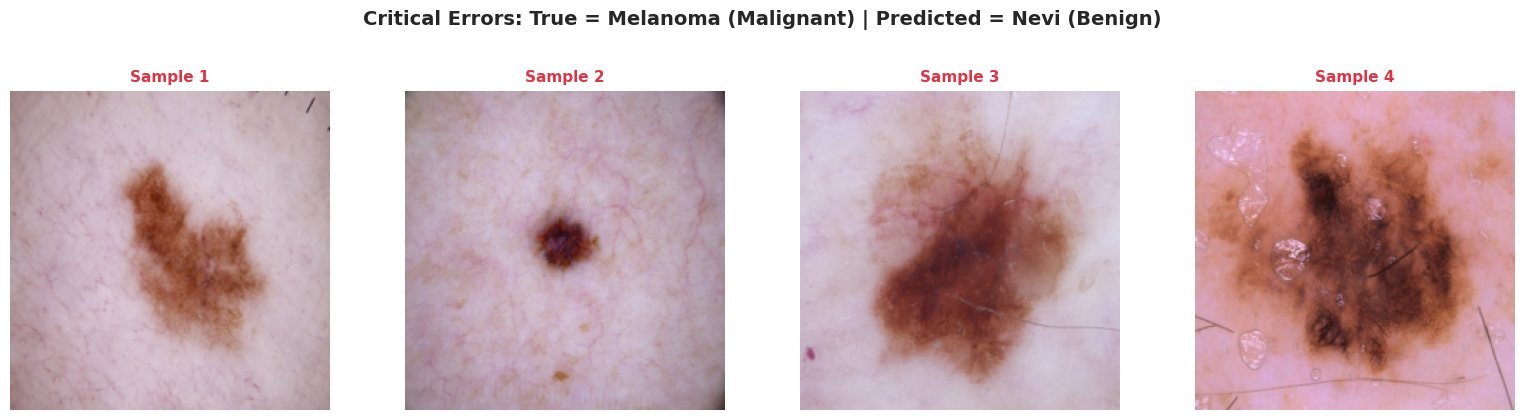

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

print("Searching for False Negative examples (True: Melanoma, Pred: Nevi)...")

# Các nhãn: mel là 4, nv là 5 (dựa theo thứ tự abc của bộ dữ liệu bạn làm)
TRUE_LABEL_MEL = 4
PRED_LABEL_NV = 5

misclassified_images = []
misclassified_true = []
misclassified_pred = []

# Tìm các ảnh bị đoán sai
vit_eval_model.eval()
with torch.no_grad():
    for inputs, labels in testloader:
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.long)
        outputs = vit_eval_model(inputs)
        _, predicted = torch.max(outputs, 1)

        # Lọc ra những ca True là mel (4) nhưng Pred là nv (5)
        for i in range(len(labels)):
            if labels[i] == TRUE_LABEL_MEL and predicted[i] == PRED_LABEL_NV:
                misclassified_images.append(inputs[i].cpu())
                if len(misclassified_images) == 4: # Lấy đủ 4 tấm thì dừng
                    break
        if len(misclassified_images) == 4:
            break

# Hàm để khử chuẩn hóa (un-normalize) ảnh giúp hiển thị lại màu gốc
def imshow_unnormalized(img, ax, title):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1) # Ép giá trị về [0, 1]
    ax.imshow(img)
    ax.set_title(title, fontsize=11, fontweight='bold', color='#dc3545')
    ax.axis('off')

# Vẽ 4 bức ảnh ra
if len(misclassified_images) > 0:
    fig, axes = plt.subplots(1, len(misclassified_images), figsize=(16, 4))
    fig.suptitle("Critical Errors: True = Melanoma (Malignant) | Predicted = Nevi (Benign)", fontsize=14, fontweight='bold', y=1.05)

    # Xử lý trường hợp chỉ tìm được 1 ảnh
    if len(misclassified_images) == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        imshow_unnormalized(misclassified_images[i], ax, f"Sample {i+1}")

    plt.tight_layout()
    plt.savefig('misclassified_samples.png', dpi=300, bbox_inches='tight')
    print("✅ Đã lưu thành công ảnh 'misclassified_samples.png'")
    plt.show()
else:
    print("Không tìm thấy ca nhầm lẫn nào loại này trong batch vừa test!")

FREEZE BACKBONE

In [8]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 5
criterion = nn.CrossEntropyLoss()

print("======================================================")
print("   STRATEGY: FREEZE BACKBONE (HAM10000 - 7 Classes)   ")
print("======================================================\n")

# ==========================================
# 1. RESNET-18: FREEZE BACKBONE
# ==========================================
print("🚀 STARTING RESNET-18 (FREEZE BACKBONE)...")
resnet_frozen = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in resnet_frozen.parameters():
    param.requires_grad = False

num_ftrs = resnet_frozen.fc.in_features
resnet_frozen.fc = nn.Linear(num_ftrs, 7)
resnet_frozen = resnet_frozen.to(device)

optimizer_resnet_frozen = optim.Adam(resnet_frozen.fc.parameters(), lr=0.001)

# ---> THÊM 2 MẢNG NÀY ĐỂ LƯU DỮ LIỆU
train_losses_resnet_fb = []
test_accuracies_resnet_fb = []

start_time_resnet_frozen = time.time()
for epoch in range(num_epochs):
    resnet_frozen.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.long)

        optimizer_resnet_frozen.zero_grad()
        outputs = resnet_frozen(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet_frozen.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(trainloader.dataset)
    train_losses_resnet_fb.append(epoch_loss) # LƯU LOSS

    resnet_frozen.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.long)
            outputs = resnet_frozen(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    test_accuracies_resnet_fb.append(epoch_acc) # LƯU ACCURACY
    print(f"ResNet Frozen - Epoch [{epoch+1}/{num_epochs}] | Test Acc: {epoch_acc:.2f}%")

print(f"✅ ResNet-18 Frozen Time: {(time.time() - start_time_resnet_frozen)/60:.2f} minutes\n")

# 3. LƯU TRỌNG SỐ RESNET-18 (FREEZE)
torch.save(resnet_frozen.state_dict(), 'resnet18_ham10000_frozen.pth')
print("✅ Đã lưu trọng số ResNet-18 (Frozen) thành công!")


# ==========================================
# 2. VIT-B_16: FREEZE BACKBONE
# ==========================================
print("🚀 STARTING VIT-B_16 (FREEZE BACKBONE)...")
vit_frozen = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

for param in vit_frozen.parameters():
    param.requires_grad = False

num_ftrs_vit = vit_frozen.heads.head.in_features
vit_frozen.heads.head = nn.Linear(num_ftrs_vit, 7)
vit_frozen = vit_frozen.to(device)

optimizer_vit_frozen = optim.Adam(vit_frozen.heads.head.parameters(), lr=0.001)

# ---> THÊM 2 MẢNG NÀY ĐỂ LƯU DỮ LIỆU
train_losses_vit_fb = []
test_accuracies_vit_fb = []

start_time_vit_frozen = time.time()
for epoch in range(num_epochs):
    vit_frozen.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.long)

        optimizer_vit_frozen.zero_grad()
        outputs = vit_frozen(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_vit_frozen.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(trainloader.dataset)
    train_losses_vit_fb.append(epoch_loss) # LƯU LOSS

    vit_frozen.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.long)
            outputs = vit_frozen(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    test_accuracies_vit_fb.append(epoch_acc) # LƯU ACCURACY
    print(f"ViT Frozen - Epoch [{epoch+1}/{num_epochs}] | Test Acc: {epoch_acc:.2f}%")

print(f"✅ ViT-B_16 Frozen Time: {(time.time() - start_time_vit_frozen)/60:.2f} minutes")

# 4. LƯU TRỌNG SỐ VIT-B_16 (FREEZE)
torch.save(vit_frozen.state_dict(), 'vit_b16_ham10000_frozen.pth')
print("✅ Đã lưu trọng số ViT-B_16 (Frozen) thành công!")

   STRATEGY: FREEZE BACKBONE (HAM10000 - 7 Classes)   

🚀 STARTING RESNET-18 (FREEZE BACKBONE)...
ResNet Frozen - Epoch [1/5] | Test Acc: 71.44%
ResNet Frozen - Epoch [2/5] | Test Acc: 73.99%
ResNet Frozen - Epoch [3/5] | Test Acc: 74.74%
ResNet Frozen - Epoch [4/5] | Test Acc: 75.24%
ResNet Frozen - Epoch [5/5] | Test Acc: 76.64%
✅ ResNet-18 Frozen Time: 6.24 minutes

✅ Đã lưu trọng số ResNet-18 (Frozen) thành công!
🚀 STARTING VIT-B_16 (FREEZE BACKBONE)...
ViT Frozen - Epoch [1/5] | Test Acc: 75.39%
ViT Frozen - Epoch [2/5] | Test Acc: 77.93%
ViT Frozen - Epoch [3/5] | Test Acc: 77.98%
ViT Frozen - Epoch [4/5] | Test Acc: 79.38%
ViT Frozen - Epoch [5/5] | Test Acc: 79.83%
✅ ViT-B_16 Frozen Time: 10.96 minutes
✅ Đã lưu trọng số ViT-B_16 (Frozen) thành công!


PRINT 4 TRAINING CHART

In [9]:
import matplotlib.pyplot as plt

def save_training_plot(epochs_list, loss_list, acc_list, title, filename):
    fig, ax1 = plt.subplots(figsize=(7, 4))

    # Vẽ Loss (Trục trái)
    color = '#004e92'
    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('Training Loss', color=color, fontweight='bold')
    ax1.plot(epochs_list, loss_list, marker='o', color=color, linewidth=2, label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks(epochs_list)

    # Vẽ Accuracy (Trục phải)
    ax2 = ax1.twinx()
    color = '#dc3545'
    ax2.set_ylabel('Test Accuracy (%)', color=color, fontweight='bold')
    ax2.plot(epochs_list, acc_list, marker='s', color=color, linewidth=2, linestyle='--', label='Test Acc')
    ax2.tick_params(axis='y', labelcolor=color)

    # Tiêu đề & Legend
    plt.title(title, fontweight='bold', pad=15)
    ax1.grid(True, linestyle='--', alpha=0.5)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()
    print(f"✅ Đã lưu ảnh: {filename}")

# Trục X (1 đến 5 epochs)
epoch_range = range(1, 6)

# 1. Vẽ cho ResNet-18 (FB)
save_training_plot(epoch_range, train_losses_resnet_fb, test_accuracies_resnet_fb,
                   "ResNet-18 (Freeze Backbone)", "resnet_fb_hist.png")

# 2. Vẽ cho ResNet-18 (FFT)
save_training_plot(epoch_range, train_losses_resnet, test_accuracies_resnet,
                   "ResNet-18 (Full Fine-Tuning)", "resnet_fft_hist.png")

# 3. Vẽ cho ViT-B_16 (FB)
save_training_plot(epoch_range, train_losses_vit_fb, test_accuracies_vit_fb,
                   "ViT-B_16 (Freeze Backbone)", "vit_fb_hist.png")

# 4. Vẽ cho ViT-B_16 (FFT)
save_training_plot(epoch_range, train_losses_vit, test_accuracies_vit,
                   "ViT-B_16 (Full Fine-Tuning)", "vit_fft_hist.png")

✅ Đã lưu ảnh: resnet_fb_hist.png
✅ Đã lưu ảnh: resnet_fft_hist.png
✅ Đã lưu ảnh: vit_fb_hist.png
✅ Đã lưu ảnh: vit_fft_hist.png


PRINT EVALUATION METRICS

In [12]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import torch

print("Calculating detailed metrics for all models...")

def get_detailed_metrics(model, dataloader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    top5_correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.long)
            outputs = model(inputs)

            # Top-1
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Top-5 (Lấy 5 dự đoán có xác suất cao nhất)
            _, top5_preds = outputs.topk(5, 1, True, True)
            labels_reshaped = labels.view(-1, 1).expand_as(top5_preds)
            top5_correct += (top5_preds == labels_reshaped).sum().item()
            total += labels.size(0)

    # Tính toán các chỉ số Weighted
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    top5_acc = top5_correct / total

    print(f"--- {model_name} ---")
    print(f"Precision : {precision*100:.2f}")
    print(f"Recall    : {recall*100:.2f}")
    print(f"F1-Score  : {f1*100:.2f}")
    print(f"Accuracy  : {acc*100:.2f}")
    print(f"Top-5 Acc : {top5_acc*100:.2f}\n")

# Chạy đánh giá cho cả 4 mô hình đang có trên RAM
get_detailed_metrics(resnet_frozen, testloader, "ResNet-18 (FB)")
get_detailed_metrics(resnet_model, testloader, "ResNet-18 (FFT)")
get_detailed_metrics(vit_frozen, testloader, "ViT-B_16 (FB)")
get_detailed_metrics(vit_eval_model, testloader, "ViT-B_16 (FFT)")

Calculating detailed metrics for all models...
--- ResNet-18 (FB) ---
Precision : 75.20
Recall    : 76.64
F1-Score  : 75.44
Accuracy  : 76.64
Top-5 Acc : 99.30

--- ResNet-18 (FFT) ---
Precision : 77.79
Recall    : 77.78
F1-Score  : 75.96
Accuracy  : 77.78
Top-5 Acc : 99.45

--- ViT-B_16 (FB) ---
Precision : 78.73
Recall    : 79.83
F1-Score  : 79.08
Accuracy  : 79.83
Top-5 Acc : 99.75

--- ViT-B_16 (FFT) ---
Precision : 84.60
Recall    : 84.62
F1-Score  : 83.39
Accuracy  : 84.62
Top-5 Acc : 99.70



Layer-wise Learning Rate using LLRD

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt

# =========================================================
# FIX LỖI: KHAI BÁO DEVICE NGAY TẠI ĐÂY
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("======================================================")
print("   STRATEGY: LAYER-WISE LEARNING RATE DECAY (LLRD)    ")
print("======================================================\n")

num_epochs = 5
criterion = nn.CrossEntropyLoss()

# =========================================================
# HÀM VẼ BIỂU ĐỒ VÀ TÍNH METRICS (Đã fix lỗi thiếu code)
# =========================================================
def save_training_plot(epochs_list, loss_list, acc_list, title, filename):
    fig, ax1 = plt.subplots(figsize=(7, 4))
    color = '#004e92'
    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('Training Loss', color=color, fontweight='bold')
    ax1.plot(epochs_list, loss_list, marker='o', color=color, linewidth=2, label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks(epochs_list)

    ax2 = ax1.twinx()
    color = '#dc3545'
    ax2.set_ylabel('Test Accuracy (%)', color=color, fontweight='bold')
    ax2.plot(epochs_list, acc_list, marker='s', color=color, linewidth=2, linestyle='--', label='Test Acc')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(title, fontweight='bold', pad=15)
    ax1.grid(True, linestyle='--', alpha=0.5)
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()
    print(f"✅ Đã lưu ảnh: {filename}")

def get_detailed_metrics(model, dataloader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    top5_correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.long)
            outputs = model(inputs)

            # Top-1
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Top-5
            _, top5_preds = outputs.topk(5, 1, True, True)
            labels_reshaped = labels.view(-1, 1).expand_as(top5_preds)
            top5_correct += (top5_preds == labels_reshaped).sum().item()
            total += labels.size(0)

    # Tính toán các chỉ số Weighted
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    top5_acc = top5_correct / total

    print(f"--- {model_name} ---")
    print(f"Precision : {precision*100:.2f}")
    print(f"Recall    : {recall*100:.2f}")
    print(f"F1-Score  : {f1*100:.2f}")
    print(f"Accuracy  : {acc*100:.2f}")
    print(f"Top-5 Acc : {top5_acc*100:.2f}\n")


# =========================================================
# 1. RESNET-18: LAYER-WISE LEARNING RATE DECAY
# =========================================================
print("🚀 STARTING RESNET-18 (LAYER-WISE LR)...")
resnet_llr = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_ftrs = resnet_llr.fc.in_features
resnet_llr.fc = nn.Linear(num_ftrs, 7)
resnet_llr = resnet_llr.to(device)

lr_base_res = 1e-3
decay_res = 0.85
param_groups_res = []

param_groups_res.append({'params': resnet_llr.fc.parameters(), 'lr': lr_base_res})
param_groups_res.append({'params': resnet_llr.layer4.parameters(), 'lr': lr_base_res * (decay_res**1)})
param_groups_res.append({'params': resnet_llr.layer3.parameters(), 'lr': lr_base_res * (decay_res**2)})
param_groups_res.append({'params': resnet_llr.layer2.parameters(), 'lr': lr_base_res * (decay_res**3)})
param_groups_res.append({'params': resnet_llr.layer1.parameters(), 'lr': lr_base_res * (decay_res**4)})
stem_params = list(resnet_llr.conv1.parameters()) + list(resnet_llr.bn1.parameters())
param_groups_res.append({'params': stem_params, 'lr': lr_base_res * (decay_res**5)})

optimizer_res_llr = optim.Adam(param_groups_res)

train_losses_res_llr = []
test_accuracies_res_llr = []

start_time_res = time.time()
for epoch in range(num_epochs):
    resnet_llr.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.long)

        optimizer_res_llr.zero_grad()
        outputs = resnet_llr(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_res_llr.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(trainloader.dataset)
    train_losses_res_llr.append(epoch_loss)

    resnet_llr.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.long)
            outputs = resnet_llr(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    test_accuracies_res_llr.append(epoch_acc)
    print(f"ResNet LLRD - Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_loss:.4f} | Test Acc: {epoch_acc:.2f}%")

print(f"✅ ResNet-18 LLRD Time: {(time.time() - start_time_res)/60:.2f} minutes\n")

torch.save(resnet_llr.state_dict(), 'resnet18_ham10000_llr.pth')
get_detailed_metrics(resnet_llr, testloader, "ResNet-18 (Layer-wise LR)")
save_training_plot(range(1, 6), train_losses_res_llr, test_accuracies_res_llr,
                   "ResNet-18 (Layer-wise LR)", "resnet_llr_hist.png")


# =========================================================
# 2. VIT-B_16: LAYER-WISE LEARNING RATE DECAY
# =========================================================
print("\n🚀 STARTING VIT-B_16 (LAYER-WISE LR)...")
vit_llr = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

num_ftrs_vit = vit_llr.heads.head.in_features
vit_llr.heads.head = nn.Linear(num_ftrs_vit, 7)
vit_llr = vit_llr.to(device)

lr_base_vit = 1e-3
decay_vit = 0.85
param_groups_vit = []

param_groups_vit.append({'params': vit_llr.heads.parameters(), 'lr': lr_base_vit})
param_groups_vit.append({'params': vit_llr.encoder.ln.parameters(), 'lr': lr_base_vit * (decay_vit**1)})
for i in range(11, -1, -1):
    lr_block = lr_base_vit * (decay_vit ** (12 - i))
    param_groups_vit.append({'params': vit_llr.encoder.layers[i].parameters(), 'lr': lr_block})
embed_params = [vit_llr.conv_proj.weight, vit_llr.conv_proj.bias, vit_llr.class_token, vit_llr.encoder.pos_embedding]
param_groups_vit.append({'params': embed_params, 'lr': lr_base_vit * (decay_vit**14)})

optimizer_vit_llr = optim.Adam(param_groups_vit)

train_losses_vit_llr = []
test_accuracies_vit_llr = []

start_time_vit = time.time()
for epoch in range(num_epochs):
    vit_llr.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.long)

        optimizer_vit_llr.zero_grad()
        outputs = vit_llr(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_vit_llr.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(trainloader.dataset)
    train_losses_vit_llr.append(epoch_loss)

    vit_llr.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.long)
            outputs = vit_llr(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    test_accuracies_vit_llr.append(epoch_acc)
    print(f"ViT LLRD - Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_loss:.4f} | Test Acc: {epoch_acc:.2f}%")

print(f"✅ ViT-B_16 LLRD Time: {(time.time() - start_time_vit)/60:.2f} minutes\n")

torch.save(vit_llr.state_dict(), 'vit_b16_ham10000_llr.pth')
get_detailed_metrics(vit_llr, testloader, "ViT-B_16 (Layer-wise LR)")
save_training_plot(range(1, 6), train_losses_vit_llr, test_accuracies_vit_llr,
                   "ViT-B_16 (Layer-wise LR)", "vit_llr_hist.png")